<a href="https://www.kaggle.com/code/yacarta/taskdataset?scriptVersionId=249465203" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
import torchvision
from torchvision import transforms
import torch
from torchtune.datasets import ConcatDataset 



In [4]:
transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor()
])

In [5]:
datadir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"
data_set = torchvision.datasets.ImageFolder(datadir, transformer)
data_set.classes

datadir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
data_set1 = torchvision.datasets.ImageFolder(datadir1, transformer)
data_set1.classes

datadir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
data_set2 = torchvision.datasets.ImageFolder(datadir2, transformer)
data_set2.classes

concat_dataset = ConcatDataset([data_set, data_set1, data_set2])



In [6]:
x, y = concat_dataset[15]

x


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [7]:
len(concat_dataset)

10661

In [8]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(concat_dataset, [0.8, 0.2])
print(len(test_dataset))
len(train_dataset)


2132


8529

In [9]:
from torch.utils.data import DataLoader


batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)



In [10]:
for x, y in train_loader:
    break

y

tensor([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [11]:
x.shape

torch.Size([12, 3, 64, 64])

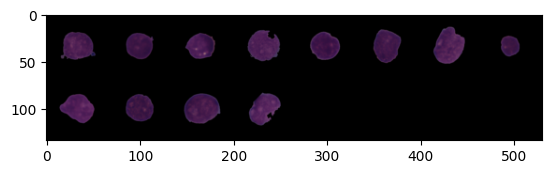

In [12]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


grid = make_grid(x).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [13]:
x.device

device(type='cpu')

# Візуалізація графіків

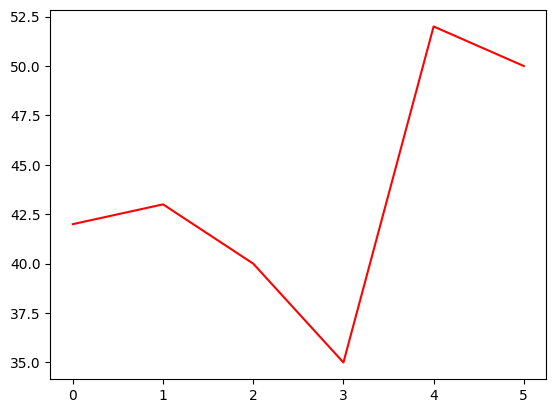

In [14]:
import matplotlib.pyplot as plt
numbers = (42, 43, 40, 35, 52, 50)
plt.plot(numbers, color="red")

Text(0.5, 1.0, 'Grafic test')

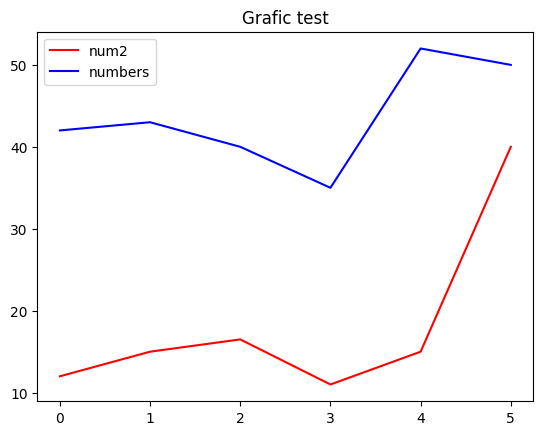

In [15]:
num2= (12, 15, 16.5 ,11, 15,40)

plt.plot(num2, color="red", label="num2")
plt.plot(numbers, color="blue", label="numbers")
plt.legend()
plt.title("Grafic test")

# Швидкість


In [16]:
import time

numbers2 = list(range(100000000))
start = time.time()
sum1 = sum(numbers2)
fin = time.time()
print("Python")
print(fin - start)


Python
0.7521302700042725


In [17]:
num_ten = torch.tensor(numbers2)
start = time.time()
sum1 = torch.sum(num_ten)
fin = time.time()
print("Torch")
print(fin - start)

Torch
0.04319047927856445
